# Exploring soil modeling in soilice

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pl

In [2]:
from soilice import model

In [3]:
from matplotlib.gridspec import GridSpec

In [4]:
def myplot(out,mytitle):

    t,dt,psie1,T1,thetaL1,thetaI1,qI,qT1,qB1,jT1,jB = (
        out.t,
        out.dt,
        out.psie,
        out.T,
        out.thetaL,
        out.thetaI,
        out.qI,
        out.qT,
        out.qB,
        out.jT,
        out.jB
    )
    
    start=-365

    fig = pl.figure(figsize=(6,5))
 
    gs = GridSpec(
    3, 1, figure=fig,
    height_ratios=[1, 0.15, 1]  # row 2 is spacer
    )
    
    ax1 = fig.add_subplot(gs[0, :])
    ax3 = fig.add_subplot(gs[2, :])
    
    
    ax1.plot(t[start:]-t[start],jT1[start:]/86400,'m',label='Ground heat flux W/m2')
    ax1.grid()
    ax1.legend()
    ax1.set_xticklabels('')
    ax1.set_xlim(0,365)
    ax1.set_ylabel('W/m2')
    fig.suptitle(mytitle)
        
    ax3.plot(np.nan,np.nan,'-k',label='Zero degree isotherm')
    cf=pl.contourf(t[start:]-t[start],z,thetaI1[start:,:].T,np.arange(0.025,0.25,0.025),cmap='Blues')
    pl.contour(t[start:]-t[start],z,T1[start:,:].T,[0],colors='k')
    pl.legend(loc=4)
    cbar = pl.colorbar(cf,orientation='horizontal', fraction=0.1, pad=0.08)
    cbar.set_label('Ice content')
    pl.grid()
    pl.ylim(0.6,0)
    pl.xlim(0,365)
    pl.gca().set_xticklabels('')
    pl.ylabel('Depth (m)')
    
    pl.subplots_adjust(wspace=0.05, hspace=0.1)

In [5]:
# Soil model options:
opts={}
opts['simulateFlow']=0.          # 0. no flow, constant total water content; 1. simulates flow
opts['gravity']=1.               # 0. for horizontal; 1. for vertical
opts['infiltration']=1.          # 0. for specified psiT; 1. for specified potential infiltration 
opts['cryoK']=0.                 # 0. K based on psie; 1. flow based on psif 
opts['cryoGradient']=0.          # 0. gradient based on psie; 1. flow based on psif 
opts['freeDrainage']=1.          # 0. no flow lower BC, 1.0 free draining lowerBC

opts['simulateTransport']=1.     # 0. no flow, constant total water content; 1. simulates heat transport
opts['withadv']=1.               # 0. turn off advection; 1. turn on advection
opts['conductionTop']=0.         # 0. no conduction on upper BC; 1. conduction based on TTop
opts['conductionBot']=1.         # 0. no conduction on lower BC; 1. conduction based on TBot

In [6]:
# Space grid
zMax=2.
dz=0.02
z=np.arange(dz/2,zMax,dz)
nz=len(z)
dz=np.zeros(nz)+dz

In [7]:
# Time grid:
t0=0
tMax=365*3+200
dt=1

In [8]:
# Setup seasonally frozen soil scenario
sfs=model(opts,rtol=1e-8)
sfs.zGrid(np.hstack([0,np.cumsum(dz)]))
sfs.tGrid(t0,tMax,dt)
sfs.readPars()
jTopBC=np.sin(sfs.t/365*2*np.pi)*2e5 #np.zeros(nt)  # Specified ground heat flux, if used.
sfs.setBCs(TBot=1,jTopBC=jTopBC)
sfs.setICs(psi0=-2,T0=1)

In [9]:
# Run seasonally frozen soil
sfsout=sfs.run()


                                    iiii  lllllll   iiii
                                   i::::i l:::::l  i::::i
                                    iiii  l:::::l   iiii
                                          l:::::l
    ssssssssss      ooooooooooo   iiiiiii  l::::l iiiiiii     cccccccccccccccc    eeeeeeeeeeee
  ss::::::::::s   oo:::::::::::oo i:::::i  l::::l i:::::i   cc:::::::::::::::c  ee::::::::::::ee
ss:::::::::::::s o:::::::::::::::o i::::i  l::::l  i::::i  c:::::::::::::::::c e::::::eeeee:::::ee
s::::::ssss:::::so:::::ooooo:::::o i::::i  l::::l  i::::i c:::::::cccccc:::::ce::::::e     e:::::e
 s:::::s  ssssss o::::o     o::::o i::::i  l::::l  i::::i c::::::c     ccccccce:::::::eeeee::::::e
   s::::::s      o::::o     o::::o i::::i  l::::l  i::::i c:::::c             e:::::::::::::::::e
      s::::::s   o::::o     o::::o i::::i  l::::l  i::::i c:::::c             e::::::eeeeeeeeeee
ssssss   s:::::s o::::o     o::::o i::::i  l::::l  i::::i c::::::c     ccccccce:::::::e
s::::

*************************************************************************
     soilice ran successfully!
               runtime:      13.95 seconds


   Energy balance rmse:  8.83e+01 J
                  bias:  8.25e+01 J
*************************************************************************



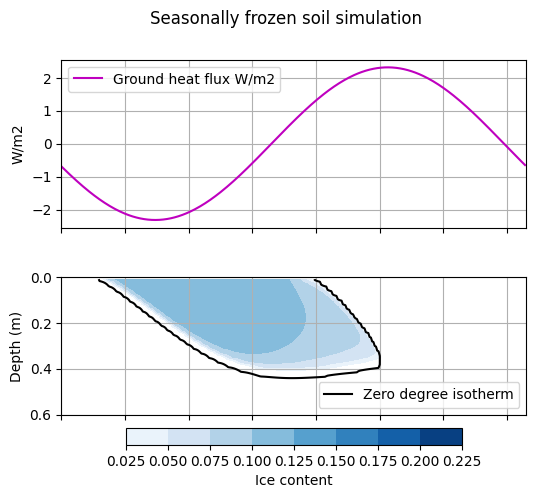

In [10]:
myplot(sfsout,'Seasonally frozen soil simulation')
pl.savefig('figures/03_SFS.svg')

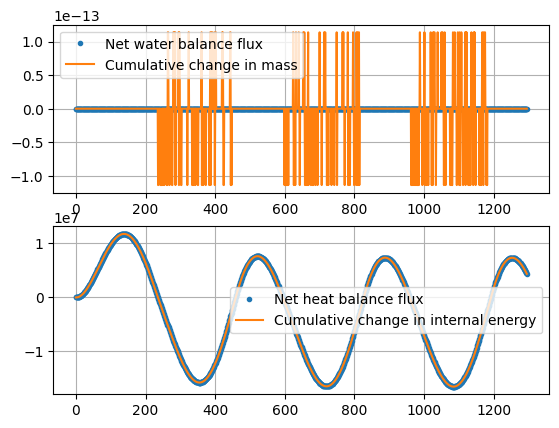

In [11]:
sfsout.plotBalance()

In [12]:
# Setup permafrost soil scenario
pfs=model(opts,rtol=1e-8)
pfs.zGrid(np.hstack([0,np.cumsum(dz)]))
pfs.tGrid(t0,tMax,dt)
pfs.readPars()
jTopBC=np.sin((pfs.t+200)/365*2*np.pi)*2e5 #np.zeros(nt)  # Specified ground heat flux, if used.
pfs.setBCs(TBot=-1,jTopBC=jTopBC)
pfs.setICs(psi0=-2,T0=-1)

In [13]:
# Run seasonally frozen soil
pfsout=pfs.run()


                                    iiii  lllllll   iiii
                                   i::::i l:::::l  i::::i
                                    iiii  l:::::l   iiii
                                          l:::::l
    ssssssssss      ooooooooooo   iiiiiii  l::::l iiiiiii     cccccccccccccccc    eeeeeeeeeeee
  ss::::::::::s   oo:::::::::::oo i:::::i  l::::l i:::::i   cc:::::::::::::::c  ee::::::::::::ee
ss:::::::::::::s o:::::::::::::::o i::::i  l::::l  i::::i  c:::::::::::::::::c e::::::eeeee:::::ee
s::::::ssss:::::so:::::ooooo:::::o i::::i  l::::l  i::::i c:::::::cccccc:::::ce::::::e     e:::::e
 s:::::s  ssssss o::::o     o::::o i::::i  l::::l  i::::i c::::::c     ccccccce:::::::eeeee::::::e
   s::::::s      o::::o     o::::o i::::i  l::::l  i::::i c:::::c             e:::::::::::::::::e
      s::::::s   o::::o     o::::o i::::i  l::::l  i::::i c:::::c             e::::::eeeeeeeeeee
ssssss   s:::::s o::::o     o::::o i::::i  l::::l  i::::i c::::::c     ccccccce:::::::e
s::::

*************************************************************************
     soilice ran successfully!
               runtime:      4.66 seconds
   Energy balance rmse:  4.60e+02 J
                  bias: -4.06e+01 J
*************************************************************************



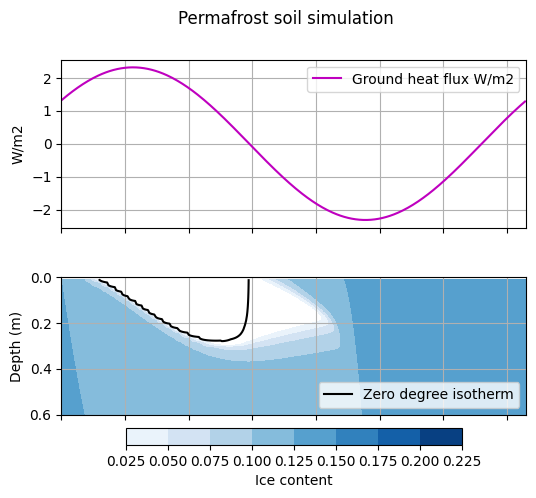

In [14]:
myplot(pfsout,'Permafrost soil simulation')
pl.savefig('figures/03_PFS.svg')

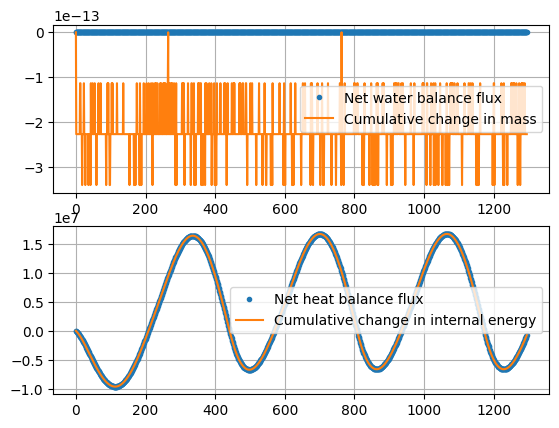

In [15]:
pfsout.plotBalance()